In [306]:
BLOCK_SIZE = 16
import math
import yaml
import os
import sys
import warnings
warnings.filterwarnings("ignore", message="Title is more than 31 characters")
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

## 0. Model msg

In [307]:
# [migrate_msg,prefill,decode,model_msg[max_seq_len,gpu_block,cpu_block]]
from benchmark_test.analysis.profile.profile import InstanceDecodeProfiler, InstanceDecodeProfilerV2, InstanceProfile, MigrationProfile


class ModelProfiler:
    def __init__(self, model_name, profile_dir, tp, cover=False):
        self.model_name = model_name
        self.profile_dir = profile_dir
        self.tp = tp 
        self.profile_data = {} # [migrate_msg,prefill,decode,model_msg[max_seq_len,gpu_block,cpu_block]]
        with open('config_model.yaml', 'r', encoding='utf-8') as file:
            self.model_config = yaml.safe_load(file)

        if os.path.exists('profile_output.yaml'):
            with open('profile_output.yaml', 'r', encoding='utf-8') as file:
                self.all_profile_data = yaml.safe_load(file) 
        else:
            self.all_profile_data = {}
        if not cover and self.model_name in self.all_profile_data and self.tp in self.all_profile_data[self.model_name]:
            self.profile_data = self.all_profile_data[self.model_name]
        else:
            self.get_model_profile()
    
    def get_model_profile(self):
        self.get_model_msg()
        self.get_migrate_msg()
        self.get_prefill_msg()
        self.get_decode_msg()
        self.save_profile(f'profile_output.yaml')
    
    def save_profile(self, save_path):
        if self.model_name not in self.all_profile_data:
            self.all_profile_data[self.model_name] = {}
        self.all_profile_data[self.model_name][self.tp] = self.profile_data
        with open(save_path, 'w', encoding='utf-8') as f:
            yaml.safe_dump_all(documents=[self.all_profile_data], stream=f, allow_unicode=True)

    def get_files_for_migrate_analysis(self, to_tp=None):
        dir = f'{self.profile_dir}/{self.model_name}/poisson/'
        # 列出dir下所有文件
        files = os.listdir(dir)
        # 过滤出包含tp的文件
        files = [f for f in files if f'_pdd_' in f]

        new_files = []
        for f in files:
            tp_list = f.split('_')[4]
            if f'{self.tp}-{to_tp}' in tp_list:
                new_files.append(f)
        new_files = [f for f in new_files if f'.log' in f]
        new_files = [f'{dir}/{f}' for f in new_files]
        # assert len(new_files) > 0, f'No profile files found in {dir} for tp {self.tp}'
        return new_files
    
    def get_migrate_msg(self):
        concurrency = 1
        # file = [
        #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_6_1_3.log',
        #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_2_1_3.log',
        #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_4_1_3.log',
        # ]
        for tp in [1, 2, 4]:
            file = self.get_files_for_migrate_analysis(tp)
            if len(file) == 0:
                continue
            print(f"Migration files: {file}")
            migration_profile = MigrationProfile(file, 0.8)
            migration_profile.get_migration_info()
            if 'migrate_msg' not in self.profile_data:
                self.profile_data['migrate_msg'] = {}
            self.profile_data['migrate_msg'][tp] = [float(x) for x in migration_profile.fit_results]
    
    def get_prefill_msg(self):
        profile_dir = f'{self.profile_dir}/{self.model_name}/poisson'
        prefill_profile = InstanceProfile(profile_dir, self.tp, enable_pd=True, is_verbose=True)
        prefill_profile.get_pdd_instance_info()
        self.profile_data['prefill_msg'] = [float(x) for x in prefill_profile.fit_results['prefill']]
    
    def get_decode_msg(self):
        profile_dir = f'{self.profile_dir}/{self.model_name}/poisson'
        decode_profile = InstanceDecodeProfilerV2(profile_dir, self.tp, enable_pd=True, is_verbose=True)
        decode_profile.get_pdd_instance_info()
        self.profile_data['decode_msg'] = [float(decode_profile.model.coef_[0]), float(decode_profile.model.coef_[1]), float(decode_profile.model.intercept_)]
    def get_model_msg(self):
        self.profile_data['model_msg'] = {
            'max_seq_len': self.model_config[self.model_name]['max_seq_len'],
            'gpu_block': self.model_config[self.model_name][self.tp]['gpu_block'],
            'cpu_block': self.model_config[self.model_name][self.tp]['cpu_block'],
        }

profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1'
m = ModelProfiler('llama-13b', profile_dir, 1, )
m = ModelProfiler('llama-13b', profile_dir, 2, )
m = ModelProfiler('llama-13b', profile_dir, 4, )


m = ModelProfiler('llama-7b', profile_dir, 1, )
m = ModelProfiler('llama-7b', profile_dir, 2, )
m = ModelProfiler('llama-7b', profile_dir, 4, )

# model_name = 'llama-13b'
# tp = 1
# profile_dir = f'{profile_dir}/{model_name}/poisson'
# prefill_profile = InstanceProfile(profile_dir, tp, enable_pd=True, is_verbose=True)
# prefill_profile.get_pdd_instance_info()
# prefill_profile.plot_token_num_vs_avg_step_time()

# decode_profile = InstanceDecodeProfiler(profile_dir, tp, enable_pd=True, is_verbose=True)
# decode_profile.get_pdd_instance_info()
# decode_profile.fit_data()

## 1. 建模

### 1.1 Prefill
$\mu_p=\frac{1}{T_{prefill}(l_{prompt})}=\frac{1}{a_1*l_{prompt}^2+b_1*l_{prompt}+c_1}$

In [308]:
class PrefillRateModel:
    def __init__(self, prompt_len, fit_args):
        self.prompt_len = prompt_len
        self.fit_args = fit_args

    def get_time(self, token_num=None):
        latency_args = self.fit_args
        # y = a*x^2 + b*x + c
        return latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
    
    def get_deal_max_rare(self):
        # 基于导数得到的处理速率，适用于高并发场景。实际上可能会长时间处于低并发场景
        latency_args = self.fit_args
        avg_token_num = self.get_time(self.in_rate * self.prompt_len) / 1000 * (self.in_rate * self.prompt_len) # 平均token数

        args = [2*latency_args[0], latency_args[1]] # 导数
        # print(args[0] * self.prompt_len + args[1], args[1])
        # return (1000 / (args[0] * avg_token_num + args[1])) / self.prompt_len
        return (1000 / (args[0] * avg_token_num + args[1])) / self.prompt_len
    
    def get_deal_rare(self, qps):
        # TODO 如何考虑请求batch到一起的情况(利用qps)
        args = self.fit_args
        return 1000 / (args[0] * self.prompt_len**2 + args[1]*self.prompt_len + args[2])
    
    def get_out_rate(self, qps=None):
        return self.get_deal_rare(qps)

### 1.2 Decode
#### 1.2.1 考虑seq_len（二元线性）
$T_{decode}=T_{decode}(batch\_size,seq\_len)=k_1*batch\_size+k_2*seq\_len+c$

In [309]:
class DecodeRateModel:
    def __init__(self, model_config, workload_msg, fit_args):
        self.model_config = model_config
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        self.fit_args = fit_args

    def solve_batch_size(self, lam):
        """
        求解 batch_size 的显式表达式

        参数:
            l_output: 输出层维度
            k2: 权重系数
            seq_len: 序列长度
            c: 常数项
            k1: 权重系数
            lam: 流量系数 λ

        返回:
            batch_size 的两个可能解（通常选择正解）
        """
        # print(f"Solving batch size for λ={lam}")
        l_output = self.output_len
        k2 = self.fit_args[1]
        seq_len = self.get_seq_len()
        c = self.fit_args[2]
        k1 = self.fit_args[0]

        s = k2 * seq_len + c  # 中间变量
        
        # 二次方程系数
        A = 1000 - k1 * lam * l_output     # 由于其余单位均基于ms，所以1需乘以1000
        B = -lam * l_output * (k1 + s)
        C = -lam * l_output * s
        
        # 计算判别式
        discriminant = B**2 - 4 * A * C
        
        if discriminant >= 0:
            batch_size1 = (-B + math.sqrt(discriminant)) / (2 * A)
            batch_size2 = (-B - math.sqrt(discriminant)) / (2 * A)
            print(f"Batch size solutions for λ={lam}: {batch_size1}, {batch_size2}")
            return batch_size1
        else:
            # 复数根（实际应用中通常选择正实数解）
            real_part = -B / (2 * A)
            imag_part = math.sqrt(-discriminant) / (2 * A)
            batch_size1, batch_size2 = (real_part + imag_part * 1j), (real_part - imag_part * 1j)
            print(f"Batch size solutions for λ={lam}: {batch_size1}, {batch_size2}")
            return None

    def solve_mu_d(self, lam):
        """
        求解μ_d的有效速率参数
        
        参数:
        l_output : float   输出层维度
        k2       : float   权重系数
        seq_len  : float   序列长度
        c        : float   常数项
        k1       : float   权重系数
        lam      : float   流量系数
        
        返回:
        mu_d1 : μ_d解
        """
        l_output = self.output_len
        k2 = self.fit_args[1]
        seq_len = self.get_seq_len()
        c = self.fit_args[2]
        k1 = self.fit_args[0]

        # 计算中间项s = k2*seq_len + c
        s = k2 * seq_len + c
        
        # 计算二次项系数
        a = l_output * s
        b = lam * l_output * (k1 - s)

        # 判别式计算
        discriminant = b**2 + 4 * lam * l_output * s * 1000  # 由于其余单位均基于ms，所以lam需乘以1000
        
        # 求解公式
        denominator = 2 * a

        
        # 计算两个解
        mu_d1 = (-b + math.sqrt(discriminant)) / denominator
        mu_d2 = (-b - math.sqrt(discriminant)) / denominator
        
        return mu_d1
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len
    
    def get_max_batch_size(self):
        gpu_block_num = self.model_config['gpu_block']
        return gpu_block_num * BLOCK_SIZE / self.get_seq_len()
    
    # 根据请求处理速度计算batch_size
    # qps: 请求处理速度（mu_d），单位req/s
    def get_batch_size_according_to_mu_d(self, qps=None):
        if qps is None:
            qps = self.in_rate
        args = self.fit_args
        batch_size = (qps * self.output_len * (args[1] * self.get_seq_len() + args[2])) / \
                    (1000 - args[0] * qps * self.output_len)
        return batch_size
    
    # 根据batch_size计算处理速度
    def get_out_rate_according_to_batch_size(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_args
        rate = 1000 * batch_size / ((args[0] * batch_size + args[1] * self.get_seq_len() + args[2]) * self.output_len)
        return rate
    
    # 根据请求到达速度计算处理速度(适用于实际情况)
    def get_out_rate(self, qps=None):
        mu_d = self.solve_mu_d(qps)
        # 选择正实数解
        # print(f"qps: {qps}, mu_d solutions: {mu_d}, batch_size(assume mu_d=qps): {self.get_batch_size_according_to_mu_d(qps)}, batch_size:{self.get_batch_size_according_to_mu_d(mu_d)}")
        return mu_d
    
    # 根据请求处理速度计算batch_size(适用于实际情况)
    def get_batch_size_according_to_qps(self, qps=None):
        bs = self.solve_batch_size(qps)
        return bs
    
    # 根据batch_size计算解码时间
    def get_decode_time(self, batch_size=None, seq_len=None):
        args = self.fit_args
        if seq_len is None:
            seq_len = self.get_seq_len()
        return (args[0] * batch_size + args[1] * self.get_seq_len() + args[2])
    
# profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4'
# m = ModelProfiler('llama-7b', profile_dir, 1)
# tp = 1
# model_profiler_msg = m.profile_data
# workload_msg = {
#     'qps': 4,
#     'prompt_len': 128, # 128,
#     'output_len': 256, # 256,
# }
# decode_model = DecodeRateModel(
#     model_profiler_msg[tp]['model_msg'], 
#     workload_msg, 
#     model_profiler_msg[tp]['decode_msg']
# )
# print(decode_model.solve_batch_size(2))
# decode_model.solve_mu_d(2)
# print(2/(decode_model.solve_mu_d(2)-2))
# print(1000/(decode_model.solve_mu_d(2)-2)/256)

#### 1.2.1 考虑seq_len_sum（二元线性）
$T_{decode}=T_{decode}(batch\_size,seq\_len)=k_1*batch\_size+k_2*seq\_len*batch\_size+c$

In [310]:
class DecodeRateModelV2:
    def __init__(self, model_config, workload_msg, fit_args):
        self.model_config = model_config
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        print(fit_args)
        self.fit_args = fit_args

    def solve_batch_size(self, lam):
        """
        求解 batch_size 的显式表达式

        参数:
            l_output: 输出层维度
            k2: 权重系数
            seq_len: 序列长度
            c: 常数项
            k1: 权重系数
            lam: 流量系数 λ

        返回:
            batch_size 的两个可能解（通常选择正解）
        """
        # # print(f"Solving batch size for λ={lam}")
        # l_output = self.output_len
        # k2 = self.fit_args[1]
        # seq_len = self.get_seq_len()
        # c = self.fit_args[2]
        # k1 = self.fit_args[0]

        # s = k2 * seq_len + c  # 中间变量
        
        # # 二次方程系数
        # A = 1000 - k1 * lam * l_output     # 由于其余单位均基于ms，所以1需乘以1000
        # B = -lam * l_output * (k1 + s)
        # C = -lam * l_output * s
        
        # # 计算判别式
        # discriminant = B**2 - 4 * A * C
        
        # if discriminant >= 0:
        #     batch_size1 = (-B + math.sqrt(discriminant)) / (2 * A)
        #     batch_size2 = (-B - math.sqrt(discriminant)) / (2 * A)
        #     print(f"Batch size solutions for λ={lam}: {batch_size1}, {batch_size2}")
        #     return batch_size1
        # else:
        #     # 复数根（实际应用中通常选择正实数解）
        #     real_part = -B / (2 * A)
        #     imag_part = math.sqrt(-discriminant) / (2 * A)
        #     batch_size1, batch_size2 = (real_part + imag_part * 1j), (real_part - imag_part * 1j)
        #     print(f"Batch size solutions for λ={lam}: {batch_size1}, {batch_size2}")
        #     return None
        mu_d = self.solve_mu_d(lam)
        bs = lam / (mu_d - lam)
        return bs

    def solve_mu_d(self, lam):
        """
        求解μ_d的有效速率参数
        
        参数:
        l_output : float   输出层维度
        k2       : float   权重系数
        seq_len  : float   序列长度
        c        : float   常数项
        k1       : float   权重系数
        lam      : float   流量系数
        
        返回:
        mu_d1 : μ_d解
        """
        l_output = self.output_len
        k2 = self.fit_args[1]
        seq_len = self.get_seq_len()
        c = self.fit_args[2]
        k1 = self.fit_args[0]

        
        # 计算二次项系数
        A = l_output * c
        B = lam * l_output * (-c + k1 + k2 * seq_len)
        C = -1000 * lam             # 由于其余单位均基于ms，所以lam需乘以1000
        

        # 判别式计算
        discriminant = B**2 - 4 * A * C
        
        # 求解公式
        denominator = 2 * A
        
        # 计算两个解
        mu_d1 = (-B + math.sqrt(discriminant)) / denominator
        mu_d2 = (-B - math.sqrt(discriminant)) / denominator
        print(f"mu_d solutions for λ={lam}: {mu_d1}, {mu_d2}")
        return mu_d1
    
    def get_seq_len(self):
        return self.prompt_len + 0.7 * self.output_len
    
    def get_max_batch_size(self):
        gpu_block_num = self.model_config['gpu_block']
        return gpu_block_num * BLOCK_SIZE / self.get_seq_len()
        # return gpu_block_num * BLOCK_SIZE / (self.prompt_len + self.output_len)
    
    # 根据请求处理速度计算batch_size
    # qps: 请求处理速度（mu_d），单位req/s
    def get_batch_size_according_to_mu_d(self, qps=None):
        if qps is None:
            qps = self.in_rate
        args = self.fit_args
        batch_size = (qps * self.output_len * args[2]) / \
                    (1000 - qps * self.output_len * (args[0] + args[1] * self.get_seq_len()))
        return batch_size
    
    # 根据batch_size计算处理速度
    def get_out_rate_according_to_batch_size(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_args
        rate = 1000 * batch_size / ((args[0] * batch_size + args[1] * self.get_seq_len() * batch_size + args[2]) * self.output_len)
        return rate
    
    # 根据请求到达速度计算处理速度(适用于实际情况)
    def get_out_rate(self, qps=None):
        mu_d = self.solve_mu_d(qps)
        # 选择正实数解
        # print(f"qps: {qps}, mu_d solutions: {mu_d}, batch_size(assume mu_d=qps): {self.get_batch_size_according_to_mu_d(qps)}, batch_size:{self.get_batch_size_according_to_mu_d(mu_d)}")
        return mu_d
    
    # 根据请求处理速度计算batch_size(适用于实际情况)
    def get_batch_size_according_to_qps(self, qps=None):
        bs = self.solve_batch_size(qps)
        return bs
    
    # 根据batch_size计算解码时间
    def get_decode_time(self, batch_size=None, seq_len=None):
        args = self.fit_args
        if seq_len is None:
            seq_len = self.get_seq_len()
        return (args[0] * batch_size + args[1] * self.get_seq_len() * batch_size + args[2])

### 1.3 Migration

In [311]:
class MigrationRateModel:
    def __init__(self, prompt_len, fit_args):
        self.prompt_len = prompt_len
        self.fit_args = fit_args

    def get_rate(self):
        args = self.fit_args
        migrate_time = (args[0] * self.prompt_len / BLOCK_SIZE + args[1]) + 50
        print(f'Migration time : {migrate_time}')
        return 1000 / migrate_time

### 1.4 分离式建模

In [312]:
class DisaggregationRateModel:
    def __init__(self, model_profiler_msg, workload_msg, placement):
        prefill_tps, decode_tps = placement
        self.is_pd = True

        self.qps = workload_msg['qps']
        self.output_len = workload_msg['output_len']
        self.prompt_len = workload_msg['prompt_len']

        self.prefill_tps = prefill_tps
        self.decode_tps = decode_tps

        self.prefill_models = []
        self.decode_models = []
        self.prefill_out_rates = []
        for tp in prefill_tps:
            prefill_model = PrefillRateModel(workload_msg['prompt_len'], model_profiler_msg[tp]['prefill_msg'])
            self.prefill_models.append(prefill_model)
            # self.prefill_out_rates.append(prefill_model.get_out_rate())
        
        from_tp = prefill_tps[0]
        to_tp = decode_tps[0]
        # TODO 目前只考虑单个迁移节点
        self.migration_model = MigrationRateModel(workload_msg['prompt_len'], model_profiler_msg[from_tp]['migrate_msg'][to_tp])
        self.migrateion_rate = self.migration_model.get_rate() * min(len(prefill_tps), len(decode_tps))

        for tp in decode_tps:
            decode_model = DecodeRateModelV2(
                model_profiler_msg[tp]['model_msg'], 
                workload_msg, 
                model_profiler_msg[tp]['decode_msg']
            )
            self.decode_models.append(decode_model)
    def get_prefill_qps_list(self):
        # 根据总qps，计算各个prefill模型的qps。（按照GPU数划分）
        qps_list = []
        gpu_sum = sum(self.prefill_tps)
        for tp in self.prefill_tps:
            qps_list.append(self.qps * tp / gpu_sum)
        return qps_list
    
    def get_prefill_rate(self, qps=None):
        if qps is None:
            prefill_rates = [pm.get_out_rate() for pm in self.prefill_models]
        else:
            prefill_rates = []
            for prefill_model, q in zip(self.prefill_models, qps):
                prefill_rates.append(prefill_model.get_out_rate(q))
        return prefill_rates 
    
    def get_decode_rate_according_to_bs(self, batch_size=None):
        total_rate = 0
        if batch_size is None:
            batch_size = [dm.get_max_batch_size() for dm in self.decode_models]
        for decode_model, bs in zip(self.decode_models, batch_size):
            total_rate += decode_model.get_out_rate_according_to_batch_size(bs)
        return total_rate  
    
    def get_decode_in_rate(self):
        print(f"Decode_in_rate: Min(Sum prefill rates: {sum(self.get_prefill_rate())}, Migration rate: {self.migrateion_rate}, QPS: {self.qps})")
        return min(sum(self.get_prefill_rate()), self.migrateion_rate, self.qps)
    
    def get_decode_qps_list(self, qps=None):
        # 根据总qps，计算各个decode模型的qps。（按照GPU数划分）
        qps_list = []
        gpu_sum = sum(self.decode_tps)
        for tp in self.decode_tps:
            qps_list.append(qps * tp / gpu_sum)
        return qps_list

    def get_decode_rate(self, qps=None):
        decode_rates = []
        for decode_model, q in zip(self.decode_models, qps):
            decode_rates.append(decode_model.get_out_rate(q))
        return decode_rates   
    
    
    def get_rate_msg(self): # TODO
        prefill_qps_list = self.get_prefill_qps_list()
        prefill_rates = self.get_prefill_rate(prefill_qps_list)
        prefill_latency = [1000 / (prefill_rate - self.qps) if prefill_rate > self.qps else float('inf')
                           for prefill_rate in prefill_rates]
        fit_prefill_time = [dm.get_time(self.prompt_len) for dm in self.prefill_models]

        migration_rate = self.migrateion_rate

        decode_total_in_rate = self.get_decode_in_rate()
        decode_qps_list = self.get_decode_qps_list(decode_total_in_rate)        # 各个decode模型的qps
        decode_rates = self.get_decode_rate(decode_qps_list)                    # 各个decode模型的处理速率
        decode_latency = [1000 / (decode_deal_rate - decode_in_rate) / self.output_len if decode_deal_rate > decode_in_rate else float('inf')
                          for decode_deal_rate, decode_in_rate in zip(decode_rates, decode_qps_list)]
        fit_batch_size = [dm.get_batch_size_according_to_qps(q) for dm, q in zip(self.decode_models, decode_qps_list)] # 各个decode模型的batch_size（fit）
        max_batch_size = [dm.get_max_batch_size() for dm in self.decode_models]
        fit_decode_time = [dm.get_decode_time(bs) for dm, bs in zip(self.decode_models, fit_batch_size)]
        return {
            'prefill_qps_list': prefill_qps_list,
            'prefill_rate': prefill_rates,
            'prefill_latency': prefill_latency,
            'fit_prefill_time': fit_prefill_time,
            'migration_rate': migration_rate,
            'decode_in_rate': decode_qps_list,
            'decode_rate': decode_rates,
            'decode_latency' : decode_latency,
            'fit_batch_size': fit_batch_size,
            'fit_decode_time': fit_decode_time,
            'max_batch_size': max_batch_size,
            'max_decode_rate': [dm.get_out_rate_according_to_batch_size() for dm in self.decode_models],
        }


### 1.5 聚合式建模
#### 1.5.1 考虑seq_len

In [313]:
from sympy import symbols, solve
class AggregationRateModelBase:
    def __init__(self, model_profiler_msg, workload_msg, tp):
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        self.fit_prefill_args = model_profiler_msg[tp]['prefill_msg']
        self.fit_decode_args = model_profiler_msg[tp]['decode_msg']

        gpu_block_num = model_profiler_msg[tp]['model_msg']['gpu_block']
        self.max_batch_size = gpu_block_num * BLOCK_SIZE / self.get_seq_len()
        self.max_seq_len = model_profiler_msg[tp]['model_msg']['max_seq_len']
    def solve_mu_p(self, lam):
        """
        同时考虑prefill和decode时延
        """
        prompt_len = self.prompt_len
        output_len = self.output_len
        seq_len = self.get_seq_len()
        a = self.fit_prefill_args[0]
        a = 0.0
        b = self.fit_prefill_args[1]
        c = self.fit_prefill_args[2]

        k1 = self.fit_decode_args[0]
        k2 = self.fit_decode_args[1]
        k3 = self.fit_decode_args[2]

        A = c + (k2 * seq_len + k3) * output_len
        B = (b * prompt_len + k1 * output_len) - 2 * lam * (c + (k2 * seq_len + k3) * output_len)
        C = a * lam**2 * prompt_len**2 - (b * prompt_len + k1 * output_len) * lam**2 + lam**2 * (c + (k2 * seq_len + k3) * output_len) - 1000 * lam
        D = 1000 * lam**2

        x = symbols('x')
        roots = solve(A * x**3 + B * x**2 + C * x + D, x)
        print("同时考虑prefill和decode时延, SymPy 求解结果：", roots)
        for r in roots:
            if r.is_real and r > 0:
                print("  选择的解：", r)

    def solve_mu_d(self, lam):
        """
        只考虑decode时延
        """
        l_output = self.output_len
        k2 = self.fit_decode_args[1]
        seq_len = self.get_seq_len()
        c = self.fit_decode_args[2]
        k1 = self.fit_decode_args[0]

        # 计算中间项s = k2*seq_len + c
        s = k2 * seq_len + c
        
        # 计算二次项系数
        a = l_output * s
        b = lam * l_output * (k1 - s)

        # 判别式计算
        discriminant = b**2 + 4 * lam * l_output * s * 1000  # 由于其余单位均基于ms，所以lam需乘以1000
        
        # 求解公式
        denominator = 2 * a
        
        # 计算两个解
        mu_d1 = (-b + math.sqrt(discriminant)) / denominator
        mu_d2 = (-b - math.sqrt(discriminant)) / denominator
        print(f"只考虑decode时延, λ={lam}, mu_d solutions: {mu_d1}, {mu_d2}")
        print(f"  batch_size:{lam / (mu_d1 - lam)}")
        return mu_d1
    
    def solve_batch_size(self, lam):
        prompt_len = self.prompt_len
        output_len = self.output_len
        seq_len = self.get_seq_len()
        a = self.fit_prefill_args[0]
        # a = 0.0
        b = self.fit_prefill_args[1]
        c = self.fit_prefill_args[2]

        k1 = self.fit_decode_args[0]
        k2 = self.fit_decode_args[1]
        k3 = self.fit_decode_args[2]
        A = lam * a * prompt_len**2
        B = lam * a * prompt_len**2 + lam * (b * prompt_len + k1 * output_len) - 1000
        C = lam * (b * prompt_len + k1 * output_len + c + (k2 * seq_len + k3) * output_len)
        D = lam * (c + (k2 * seq_len + k3) * output_len)
        # print(A, B, C, D)
        x = symbols('x')
        roots = solve(A * x**3 + B * x**2 + C * x + D, x)
        # print("SymPy 求解结果[batch size]：", roots)
        res = []
        for r in roots:
            if r.is_real and r > 0:
                # print("  选择的解：", r)
                # print(f"  batch_size:{r}, mu_d:{lam + lam / r}")
                res.append(r)
            # 虚部很小
            elif r.as_real_imag()[1] < 1e-5 and r.as_real_imag()[0] > 0:
                # print("  选择的解（虚部很小）：", r)
                real_r = r.as_real_imag()[0]
                # print(f"  batch_size:{real_r}, mu_d:{lam + lam / real_r}")
                res.append(real_r)
        return res

    def get_prefill_time(self, token_num=None):
        # y = a*x^2 + b*x + c
        latency_args = self.fit_prefill_args
        time = 0
        while token_num > self.max_seq_len:
            time += latency_args[0] * self.max_seq_len**2 + latency_args[1] * self.max_seq_len + latency_args[2]
            token_num -= self.max_seq_len
        # 计算剩余token_num的时间
        time += latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
        return time
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len

    def get_decode_time(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_decode_args
        time = (args[0] * batch_size + args[1] * self.get_seq_len() + args[2]) * self.output_len
        return time
    
    def get_batch_size(self,qps):
        return self.solve_batch_size(qps)[0]
    
    # def get_out_rate(self, batch_size):
    #     prefill_time = self.get_prefill_time(batch_size * self.prompt_len)
    #     rate = batch_size / (prefill_time / 1000 + self.get_decode_time(batch_size) / 1000)
    #     return rate
    def get_out_rate(self, qps):
        # rate = self.solve_mu_p(qps)
        # rate = self.solve_mu_d(qps)
        bs = min(self.solve_batch_size(qps))
        rate = qps + qps / bs
        return rate


#### 1.5.2 考虑seq_len_sum

In [314]:

# 考虑seq_len_sum
class AggregationRateModelBaseV2:
    def __init__(self, model_profiler_msg, workload_msg, tp):
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        self.fit_prefill_args = model_profiler_msg[tp]['prefill_msg']
        self.fit_decode_args = model_profiler_msg[tp]['decode_msg']

        gpu_block_num = model_profiler_msg[tp]['model_msg']['gpu_block']
        self.max_batch_size = gpu_block_num * BLOCK_SIZE / self.get_seq_len()
        self.max_seq_len = model_profiler_msg[tp]['model_msg']['max_seq_len']
    
    def get_value_according_to_lam(self, lam, x):
        prompt_len = self.prompt_len
        output_len = self.output_len
        seq_len = self.get_seq_len()
        a = self.fit_prefill_args[0]
        # a = 0.0
        b = self.fit_prefill_args[1]
        c = self.fit_prefill_args[2]

        k1 = self.fit_decode_args[0]
        k2 = self.fit_decode_args[1]
        k3 = self.fit_decode_args[2]
        A = lam * a * prompt_len**2
        B = lam * a * prompt_len**2 + lam * (b * prompt_len + (k1 + k2 * seq_len) * output_len) - 1000
        C = lam * (b * prompt_len + k1 * output_len + c + (k2 * seq_len + k3) * output_len)
        D = lam * (c + k3 * output_len)
        print(A, B, C, D)
        res = []
        for x_ in x:
            res.append(A * x_**3 + B * x_**2 + C * x_ + D)
        return res
    
    def solve_batch_size(self, lam):
        prompt_len = self.prompt_len
        output_len = self.output_len
        seq_len = self.get_seq_len()
        a = self.fit_prefill_args[0]
        # a = 0.0
        b = self.fit_prefill_args[1]
        c = self.fit_prefill_args[2]

        k1 = self.fit_decode_args[0]
        k2 = self.fit_decode_args[1]
        k3 = self.fit_decode_args[2]
        A = lam * a * prompt_len**2
        B = lam * a * prompt_len**2 + lam * (b * prompt_len + (k1 + k2 * seq_len) * output_len) - 1000
        C = lam * (b * prompt_len + k1 * output_len + c + (k2 * seq_len + k3) * output_len)
        D = lam * (c + k3 * output_len)
        # print(A, B, C, D)
        x = symbols('x')
        roots = solve(A * x**3 + B * x**2 + C * x + D, x)
        print("SymPy 求解结果[batch size]：", roots)
        res = []
        for r in roots:
            if r.is_real and r > 0:
                # print("  选择的解：", r)
                # print(f"  batch_size:{r}, mu_d:{lam + lam / r}")
                res.append(r)
            # 虚部很小
            elif abs(r.as_real_imag()[1]) < 1e-5 and r.as_real_imag()[0] > 0:
                # print("  选择的解（虚部很小）：", r)
                real_r = r.as_real_imag()[0]
                # print(f"  batch_size:{real_r}, mu_d:{lam + lam / real_r}")
                res.append(real_r)
        if len(res) == 0:
            # print("SymPy 求解结果[batch size]：", roots)
            # print(f"A={A}, B={B}, C={C}, D={D}")
            res.append(self.max_batch_size)
        return res

    def get_prefill_time(self, token_num=None):
        # y = a*x^2 + b*x + c
        latency_args = self.fit_prefill_args
        time = 0
        while token_num > self.max_seq_len:
            time += latency_args[0] * self.max_seq_len**2 + latency_args[1] * self.max_seq_len + latency_args[2]
            token_num -= self.max_seq_len
        # 计算剩余token_num的时间
        time += latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
        return time
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len

    def get_decode_time(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_decode_args
        time = (args[0] * batch_size + args[1] * self.get_seq_len() * batch_size + args[2]) * self.output_len
        return time
    
    def get_batch_size(self,qps):
        return self.solve_batch_size(qps)[0]
    
    # def get_out_rate(self, batch_size):
    #     prefill_time = self.get_prefill_time(batch_size * self.prompt_len)
    #     rate = batch_size / (prefill_time / 1000 + self.get_decode_time(batch_size) / 1000)
    #     return rate
    def get_out_rate(self, qps):
        # rate = self.solve_mu_p(qps)
        # rate = self.solve_mu_d(qps)
        bs = min(self.solve_batch_size(qps))
        rate = qps + qps / bs
        return rate
    
    def get_time(self, bs):
        prefill_time = self.get_prefill_time(bs * self.prompt_len)
        decode_time = self.get_decode_time(bs)
        return (prefill_time + decode_time) / bs


#### 1.5.3 改变prefill time求解方法

In [315]:
class AggregationRateModelBaseV3:
    def __init__(self, model_profiler_msg, workload_msg, tp):
        self.prompt_len = workload_msg['prompt_len']
        self.output_len = workload_msg['output_len']
        self.fit_prefill_args = model_profiler_msg[tp]['prefill_msg']
        self.fit_decode_args = model_profiler_msg[tp]['decode_msg']

        gpu_block_num = model_profiler_msg[tp]['model_msg']['gpu_block']
        self.max_batch_size = gpu_block_num * BLOCK_SIZE / self.get_seq_len()
        self.max_seq_len = model_profiler_msg[tp]['model_msg']['max_seq_len']
    
    def solve_mu(self, lam):
        prompt_len = self.prompt_len
        output_len = self.output_len
        seq_len = self.get_seq_len()
        a = self.fit_prefill_args[0]
        # a = 0.0
        b = self.fit_prefill_args[1]
        c = self.fit_prefill_args[2]

        k1 = self.fit_decode_args[0]
        k2 = self.fit_decode_args[1]
        k3 = self.fit_decode_args[2]
        A = k3 * output_len
        B = lam * (a * prompt_len**2 + b * prompt_len + c + (k1 + k2 * seq_len) * output_len - k3 * output_len)
        C = -1000 * lam

        # 判别式计算
        discriminant = B**2 - 4 * A * C
        
        # 求解公式
        denominator = 2 * A
        
        # 计算两个解
        mu1 = (-B + math.sqrt(discriminant)) / denominator
        mu2 = (-B - math.sqrt(discriminant)) / denominator
        print(f"λ={lam}, bs solutions: {mu1}, {mu2}")
        return [mu1]

    def solve_batch_size(self, lam):
        prompt_len = self.prompt_len
        output_len = self.output_len
        seq_len = self.get_seq_len()
        a = self.fit_prefill_args[0]
        # a = 0.0
        b = self.fit_prefill_args[1]
        c = self.fit_prefill_args[2]

        k1 = self.fit_decode_args[0]
        k2 = self.fit_decode_args[1]
        k3 = self.fit_decode_args[2]

        s = a * prompt_len**2 + b * prompt_len + c + (k1 + k2 * seq_len) * output_len

        A = -(lam * s - 1000)
        B = -(lam * s + lam * k3 * output_len)
        C = -(lam * k3 * output_len)

        # 判别式计算
        discriminant = B**2 - 4 * A * C
        
        # 求解公式
        denominator = 2 * A
        
        # 计算两个解
        bs1 = (-B + math.sqrt(discriminant)) / denominator
        bs2 = (-B - math.sqrt(discriminant)) / denominator
        print(f"λ={lam}, bs solutions: {bs1}, {bs2}")
        return [bs1]
        
    
    # def solve_batch_size(self, lam):
    #     prompt_len = self.prompt_len
    #     output_len = self.output_len
    #     seq_len = self.get_seq_len()
    #     a = self.fit_prefill_args[0]
    #     # a = 0.0
    #     b = self.fit_prefill_args[1]
    #     c = self.fit_prefill_args[2]

    #     k1 = self.fit_decode_args[0]
    #     k2 = self.fit_decode_args[1]
    #     k3 = self.fit_decode_args[2]
    #     A = lam * a * prompt_len**2
    #     B = lam * a * prompt_len**2 + lam * (b * prompt_len + (k1 + k2 * seq_len) * output_len) - 1000
    #     C = lam * (b * prompt_len + k1 * output_len + c + (k2 * seq_len + k3) * output_len)
    #     D = lam * (c + k3 * output_len)
    #     # print(A, B, C, D)
    #     x = symbols('x')
    #     roots = solve(A * x**3 + B * x**2 + C * x + D, x)
    #     print("SymPy 求解结果[batch size]：", roots)
    #     res = []
    #     for r in roots:
    #         if r.is_real and r > 0:
    #             # print("  选择的解：", r)
    #             # print(f"  batch_size:{r}, mu_d:{lam + lam / r}")
    #             res.append(r)
    #         # 虚部很小
    #         elif abs(r.as_real_imag()[1]) < 1e-5 and r.as_real_imag()[0] > 0:
    #             # print("  选择的解（虚部很小）：", r)
    #             real_r = r.as_real_imag()[0]
    #             # print(f"  batch_size:{real_r}, mu_d:{lam + lam / real_r}")
    #             res.append(real_r)
    #     if len(res) == 0:
    #         # print("SymPy 求解结果[batch size]：", roots)
    #         # print(f"A={A}, B={B}, C={C}, D={D}")
    #         res.append(self.max_batch_size)
    #     return res

    def get_prefill_time(self):
        # y = a*x^2 + b*x + c
        latency_args = self.fit_prefill_args
        time = 0
        token_num = self.prompt_len
        while token_num > self.max_seq_len:
            time += latency_args[0] * self.max_seq_len**2 + latency_args[1] * self.max_seq_len + latency_args[2]
            token_num -= self.max_seq_len
        # 计算剩余token_num的时间
        time += latency_args[0] * token_num**2 + latency_args[1] * token_num + latency_args[2]
        return time
    
    def get_seq_len(self):
        return self.prompt_len + 0.5 * self.output_len

    def get_decode_time(self, batch_size=None):
        if batch_size is None:
            batch_size = self.get_max_batch_size()
        args = self.fit_decode_args
        time = (args[0] * batch_size + args[1] * self.get_seq_len() * batch_size + args[2]) * self.output_len
        return time
    
    def get_batch_size(self,qps):
        return self.solve_batch_size(qps)[0]
    
    # def get_out_rate(self, batch_size):
    #     prefill_time = self.get_prefill_time(batch_size * self.prompt_len)
    #     rate = batch_size / (prefill_time / 1000 + self.get_decode_time(batch_size) / 1000)
    #     return rate
    def get_out_rate(self, qps):
        # rate = self.solve_mu_p(qps)
        # rate = self.solve_mu_d(qps)
        bs = min(self.solve_batch_size(qps))
        rate = qps + qps / bs
        return rate
    
    def get_time(self, bs):
        prefill_time = bs * self.get_prefill_time()
        decode_time = self.get_decode_time(bs)
        return (prefill_time + decode_time) / bs


In [316]:

class AggregationRateModel:
    def __init__(self, model_profiler_msg, workload_msg, placement):
        assert len(placement[1]) == 0
        self.is_pd = False
        tps = placement[0]
        self.tps = tps
        self.qps = workload_msg['qps']
        self.output_len = workload_msg['output_len']

        self.models = []
        for tp in tps:
            self.models.append(AggregationRateModelBaseV3(model_profiler_msg, workload_msg, tp))
    # def get_out_rate(self, batch_size=None):
    #     total_rate = 0
    #     for model,bs in zip(self.models, batch_size):
    #         total_rate += model.get_out_rate(bs)
    #     return total_rate
    def get_qps_list(self, qps=None):
        # 根据总qps，计算各个decode模型的qps。（按照GPU数划分）
        qps_list = []
        gpu_sum = sum(self.tps)
        for tp in self.tps:
            qps_list.append(qps * tp / gpu_sum)
        return qps_list

    def get_rate(self, qps=None):
        rates = []
        for model, q in zip(self.models, qps):
            rates.append(model.get_out_rate(q))
        return rates 
    
    def get_rate_msg(self): # TODO
        qps_list = self.get_qps_list(self.qps)
        rates = self.get_rate(qps_list)
        # print(rates)
        latency = [1000 / (rate - qps) if rate > qps else float('inf')
                           for rate,qps in zip(rates, qps_list)]
        fit_batch_size = [m.get_batch_size(q) for m, q in zip(self.models, qps_list)] # 各个模型的batch_size（fit）
        # print(fit_batch_size)
        max_batch_size = [m.max_batch_size for m in self.models]
        fit_all_decode_time = [m.get_decode_time(bs) for m, bs in zip(self.models, fit_batch_size)]
        return {
            'qps_list': qps_list,
            'out_rate': sum(rates),
            'rate': rates,
            'latency': [l / 1000 for l in latency], # s 单位
            'fit_prefill_time': [m.get_prefill_time() for m,bs in zip(self.models, fit_batch_size)],
            'fit_batch_size': fit_batch_size,
            'fit_all_decode_time': [t / 1000 for t in fit_all_decode_time], # s 单位
            'fit_decode_time': [t/self.output_len for t in fit_all_decode_time],
            'fit_time': [m.get_time(bs) for m, bs in zip(self.models, fit_batch_size)],
            'max_batch_size': max_batch_size,
        }
    

### 1.6 示例

In [317]:

def mmc_queue_analysis(C, lambda_rate, mu_rate, max_n=100):
    """
    计算M/M/C排队模型的稳态概率及性能指标
    
    参数:
        C (int): 服务台数量
        lambda_rate (float): 到达率 (λ)
        mu_rate (float): 服务率 (μ)
        max_n (int): 计算稳态概率的最大顾客数（默认100）
    
    返回:
        dict: 包含稳态概率和性能指标的字典
    """
    # 计算服务强度ρ
    rho = lambda_rate / (C * mu_rate)
    if rho >= 1:
        raise ValueError("系统不稳定：ρ ≥ 1（到达率超过服务能力）")

    # 计算P0（系统空闲概率）
    sum_p0 = sum((lambda_rate / mu_rate)**n / math.factorial(n) for n in range(C))
    sum_p0 += (lambda_rate / mu_rate)**C / (math.factorial(C) * (1 - rho))
    P0 = 1 / sum_p0

    # 计算稳态概率Pn
    Pn = []
    for n in range(max_n + 1):
        if n < C:
            Pn.append(P0 * (lambda_rate / mu_rate)**n / math.factorial(n))
        else:
            Pn.append(P0 * (lambda_rate / mu_rate)**n / (math.factorial(C) * C**(n - C)))

    # 计算关键性能指标
    Lq = (P0 * (lambda_rate / mu_rate)**C * rho) / (math.factorial(C) * (1 - rho)**2)
    Wq = Lq / lambda_rate
    Ws = Wq + 1 / mu_rate
    Ls = Lq + lambda_rate / mu_rate
    P_wait = (lambda_rate / mu_rate)**C / (math.factorial(C) * (1 - rho)) * P0  # 必须等待的概率
    return Ws

profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1'
m = ModelProfiler('llama-7b', profile_dir, 2, )
m = ModelProfiler('llama-7b', profile_dir, 4, )
# m = ModelProfiler('llama-7b', profile_dir, 8, )

m = ModelProfiler('llama-13b', profile_dir, 2, )
m = ModelProfiler('llama-13b', profile_dir, 4, )
# m = ModelProfiler('llama-13b', profile_dir, 8, )

profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-concurrency-1-pdd-4'
m = ModelProfiler('llama-7b', profile_dir, 1)
model_profiler_msg = m.profile_data
workload_msg = {
    'qps': 4,
    'prompt_len': 128, # 128, 182, 261
    'output_len': 256, # 256, 473, 491
}

res = []

instance_deploy_msg = [     # (prefill_tps, decode_tps)
    ([1,1,1,1],[])
]
# print(model_profiler_msg)
rate_model = AggregationRateModel(model_profiler_msg, workload_msg,instance_deploy_msg[0])    # 182, 473
# placement_analyzer = PlacementAnalyzer(model_profiler_msg, workload_msg, instance_deploy_msg)
msg = rate_model.get_rate_msg()
print(msg)
res.append(msg)


λ=1.0, bs solutions: 9.235645253183426, -0.8810848270677403
λ=1.0, bs solutions: 9.235645253183426, -0.8810848270677403
λ=1.0, bs solutions: 9.235645253183426, -0.8810848270677403
λ=1.0, bs solutions: 9.235645253183426, -0.8810848270677403
λ=1.0, bs solutions: 9.235645253183426, -0.8810848270677403
λ=1.0, bs solutions: 9.235645253183426, -0.8810848270677403
λ=1.0, bs solutions: 9.235645253183426, -0.8810848270677403
λ=1.0, bs solutions: 9.235645253183426, -0.8810848270677403
{'qps_list': [1.0, 1.0, 1.0, 1.0], 'out_rate': 4.433104552020471, 'rate': [1.1082761380051178, 1.1082761380051178, 1.1082761380051178, 1.1082761380051178], 'latency': [9.235645253183428, 9.235645253183428, 9.235645253183428, 9.235645253183428], 'fit_prefill_time': [56.58983676188539, 56.58983676188539, 56.58983676188539, 56.58983676188539], 'fit_batch_size': [9.235645253183426, 9.235645253183426, 9.235645253183426, 9.235645253183426], 'fit_all_decode_time': [7.810699393685976, 7.810699393685976, 7.810699393685976, 

In [318]:

res = []
instance_deploy_msg = [     # (prefill_tps, decode_tps)
    ([1],[1,1,1])
]
rate_model = DisaggregationRateModel(model_profiler_msg, workload_msg,instance_deploy_msg[0])    # 182, 473
# placement_analyzer = PlacementAnalyzer(model_profiler_msg, workload_msg, instance_deploy_msg)
msg = rate_model.get_rate_msg()
print(msg)
res.append(msg)

instance_deploy_msg = [     # (prefill_tps, decode_tps)
    ([1,1],[1,1])
]
rate_model = DisaggregationRateModel(model_profiler_msg, workload_msg,instance_deploy_msg[0])    # 182, 473
# placement_analyzer = PlacementAnalyzer(model_profiler_msg, workload_msg, instance_deploy_msg)
msg = rate_model.get_rate_msg()
print(msg)
res.append(msg)

instance_deploy_msg = [     # (prefill_tps, decode_tps)
    ([1,1,1],[1])
]
rate_model = DisaggregationRateModel(model_profiler_msg, workload_msg,instance_deploy_msg[0])    # 182, 473
# placement_analyzer = PlacementAnalyzer(model_profiler_msg, workload_msg, instance_deploy_msg)
msg = rate_model.get_rate_msg()
print(msg)
res.append(msg)

instance_deploy_msg = [     # (prefill_tps, decode_tps)
    ([1,1],[2])
]
rate_model = DisaggregationRateModel(model_profiler_msg, workload_msg,instance_deploy_msg[0])    # 182, 473
# placement_analyzer = PlacementAnalyzer(model_profiler_msg, workload_msg, instance_deploy_msg)
msg = rate_model.get_rate_msg()
print(msg)
res.append(msg)

import pandas as pd
df = pd.DataFrame(res)
df


Migration time : 195.32344036678091
[0.317601583686308, 0.0006184175846894927, 26.115148677596054]
[0.317601583686308, 0.0006184175846894927, 26.115148677596054]
[0.317601583686308, 0.0006184175846894927, 26.115148677596054]
Decode_in_rate: Min(Sum prefill rates: 17.67101757525344, Migration rate: 5.119713220912897, QPS: 4)
mu_d solutions for λ=1.3333333333333333: 1.4453991320642126, -0.13798074293787213
mu_d solutions for λ=1.3333333333333333: 1.4453991320642126, -0.13798074293787213
mu_d solutions for λ=1.3333333333333333: 1.4453991320642126, -0.13798074293787213
mu_d solutions for λ=1.3333333333333333: 1.4453991320642126, -0.13798074293787213
mu_d solutions for λ=1.3333333333333333: 1.4453991320642126, -0.13798074293787213
mu_d solutions for λ=1.3333333333333333: 1.4453991320642126, -0.13798074293787213
{'prefill_qps_list': [4.0], 'prefill_rate': [17.67101757525344], 'prefill_latency': [73.14744454795725], 'fit_prefill_time': [56.58983676188539], 'migration_rate': 5.119713220912897,

,prefill_qps_list,prefill_rate,prefill_latency,fit_prefill_time,migration_rate,decode_in_rate,decode_rate,decode_latency,fit_batch_size,fit_decode_time,max_batch_size,max_decode_rate
0,[4.0],[17.67101757525344],[73.14744454795725],[56.58983676188539],5.119713,"[1.3333333333333333, 1.3333333333333333, 1.333...","[1.4453991320642126, 1.4453991320642126, 1.445...","[34.85675419474477, 34.85675419474477, 34.8567...","[11.897772098472881, 11.897772098472881, 11.89...","[32.15421348239403, 32.15421348239403, 32.1542...","[198.22916666666669, 198.22916666666669, 198.2...","[6.109991484845975, 6.109991484845975, 6.10999..."
1,"[2.0, 2.0]","[17.67101757525344, 17.67101757525344]","[73.14744454795725, 73.14744454795725]","[56.58983676188539, 56.58983676188539]",10.239426,"[2.0, 2.0]","[2.10335549959955, 2.10335549959955]","[37.79431201179172, 37.79431201179172]","[19.350687750037363, 19.350687750037363]","[35.93716042674406, 35.93716042674406]","[198.22916666666669, 198.22916666666669]","[6.109991484845975, 6.109991484845975]"
2,"[1.3333333333333333, 1.3333333333333333, 1.333...","[17.67101757525344, 17.67101757525344, 17.6710...","[73.14744454795725, 73.14744454795725, 73.1474...","[56.58983676188539, 56.58983676188539, 56.5898...",5.119713,[4.0],[4.069286291604971],[56.37839620961514],[57.731477718645905],[55.41846129226638],[198.22916666666669],[6.109991484845975]
3,"[2.0, 2.0]","[17.67101757525344, 17.67101757525344]","[73.14744454795725, 73.14744454795725]","[56.58983676188539, 56.58983676188539]",3.994763,[3.9947630350838987],[4.124755399649619],[30.04984187379041],[30.730751367048757],[29.102816020976967],[476.30208333333337],[10.051241942020495]


## 2. 对比
暂时不考虑迁移速率的因素

暂时不考虑同一类型示例下，非对称TP

In [319]:
import pprint
from benchmark_test.analysis.main import LogAnalysis, LogAnalysis_new, ResultAnalysis


def get_model_result(model, workload_msg, instance_deploy_msg, concurrency=1, profile_dir=None, is_verbose=False):
    if profile_dir is None:
        profile_dir = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}'
    if not workload_msg['is_ShareGPT']:
        prompt_len = workload_msg['prompt_len']
        output_len = workload_msg['output_len']
        profile_dir += f'-{prompt_len}-{output_len}'
    m = ModelProfiler(model, profile_dir, 1)    # 这里假设已经profile好了，调用这个类只是获取数据
    model_profiler_msg = m.profile_data         # model_profiler_msg 包含各个tp的profile数据

    decode_tps = instance_deploy_msg[1]         # (prefill_tps, decode_tps)
    if len(decode_tps) == 0:
        rate_model = AggregationRateModel(model_profiler_msg, workload_msg, instance_deploy_msg)
    else:
        rate_model = DisaggregationRateModel(model_profiler_msg, workload_msg, instance_deploy_msg)
    msg = rate_model.get_rate_msg()
    for k,v in msg.items():
        if isinstance(v, list):
            # 是否所有值都相同
            if all(x == v[0] for x in v):
                msg[k] = v[0]
    if is_verbose:  
        pprint.pprint(msg)
    return msg

def get_value(key, fix_fields, change_field_value):
    if key in fix_fields:
        return str(fix_fields[key])
    else:
        return str(change_field_value)
    
def get_msg_from_real_result(data_tmp, is_verbose=False):
    if is_verbose:
        pprint.pprint(data_tmp)
    new_data_tmp = {
        'request_time': data_tmp['request_time'],
        'prefill_time': data_tmp['prefill_time'],
        'decode_time': data_tmp['decode_time'],
        'prefill_waiting_time': data_tmp['prefill_waiting_time'] if 'prefill_waiting_time' in data_tmp else None,
        'avg_migration_time': data_tmp['avg_migration_time'] if 'avg_migration_time' in data_tmp else None,
        'avg_migrate_waiting_time': data_tmp['avg_migrate_waiting_time'] if 'avg_migrate_waiting_time' in data_tmp else None,
    }
    decode_step_times = []
    prefill_step_times = []
    decode_bs = []
    num_killed_requests = []
    decode_avg_new_req_rates = []
    decode_finished_req_rates = []
    num_waiting_requests = []
    for k, val in data_tmp.items():
        if len(k) == 32:
            if 'prefill_step_time' in val.keys():
                prefill_step_times.append(val['prefill_step_time'])
            if 'decode_step_time' in val.keys():
                decode_step_times.append(val['decode_step_time'])
            if 'decode_bs' in val.keys():
                decode_bs.append(val['decode_bs'])
                if 'num_killed_requests' in val.keys():
                    num_killed_requests.append(val['num_killed_requests'])
                if 'decode_avg_new_req_rate' in val.keys():
                    decode_avg_new_req_rates.append(val['decode_avg_new_req_rate'])
                if 'decode_finished_req_rate' in val.keys():
                    decode_finished_req_rates.append(val['decode_finished_req_rate'])
            if 'num_waiting_requests' in val.keys():
                num_waiting_requests.append(val['num_waiting_requests'])
    if len(num_waiting_requests) > 0:
        new_data_tmp['num_waiting_requests'] = sum(num_waiting_requests) / len(num_waiting_requests)
    if len(decode_finished_req_rates) > 0:
        new_data_tmp['decode_finished_req_rate'] = sum(decode_finished_req_rates) / len(decode_finished_req_rates)
    if len(decode_avg_new_req_rates) > 0:
        new_data_tmp['decode_avg_new_req_rate'] = sum(decode_avg_new_req_rates) / len(decode_avg_new_req_rates)
    if len(prefill_step_times) > 0:
        new_data_tmp['prefill_step_time'] = sum(prefill_step_times) / len(prefill_step_times)
    if len(decode_step_times) > 0:
        new_data_tmp['decode_step_time'] = sum(decode_step_times) / len(decode_step_times)
    if len(decode_bs) > 0:
        new_data_tmp['decode_bs'] = sum(decode_bs) / len(decode_bs)
    if len(num_killed_requests) > 0:
        new_data_tmp['num_killed_requests'] = sum(num_killed_requests) / len(num_killed_requests)
    return new_data_tmp

def get_real_result(model, workload_msg, instance_deploy_msg, concurrency=1):
    log_dir = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}'
    if not workload_msg['is_ShareGPT']:
        prompt_len = workload_msg['prompt_len']
        output_len = workload_msg['output_len']
        log_dir += f'-{prompt_len}-{output_len}'
    log_dir += f'/{model}/poisson/'
    analysis = ResultAnalysis(log_dir) 
    analysis.get_all_msg()
    # analysis.get_all_msg_updata_instance_metric()

    qps = str(workload_msg['qps'])
    concurrency = str(concurrency)

    # 根据 instance_deploy_msg 得出label
    prefill_label = ','.join([str(x) for x in instance_deploy_msg[0]])
    decode_label = ','.join([str(x) for x in instance_deploy_msg[1]])
    if decode_label == '':
        label = prefill_label
    else:
        label = prefill_label + '-' + decode_label
    print(f"Get real result for model={model}, qps={qps}, concurrency={concurrency}, label={label}")
    # 获取数据
    if qps not in analysis.results:
        print(f"Analysis results: {analysis.results.keys()}")
        print(f"QPS {qps} not found in analysis results")
        return {}
    if label not in analysis.results[qps]:
        print(f"Label {label} not found in analysis results for QPS {qps}")
        return {}
    data_tmp = analysis.results[qps][label]
    # pprint.pprint(data_tmp)
    new_data_tmp = get_msg_from_real_result(data_tmp)
    return new_data_tmp

def merge_two_results(model, concurrency, real_result, model_result, workload_msg=None, instance_deploy_msg=None):
    fix_fields = {
        'model': model,
        'qps': workload_msg['qps'],
        'prompt_len': workload_msg['prompt_len'],
        'output_len': workload_msg['output_len'],
        'prefill_tps': ','.join([str(x) for x in instance_deploy_msg[0]]),
        'decode_tps': ','.join([str(x) for x in instance_deploy_msg[1]]),
        'concurrency': concurrency,
    }
    is_pd = len(instance_deploy_msg[1]) > 0
    columns_name_map = d_columns_name_map if is_pd else a_columns_name_map

    real_result_data = {**fix_fields, **real_result}
    model_result_data = {**fix_fields, **{(columns_name_map[k] if k in columns_name_map else k): v for k, v in model_result.items()}}
    
    return[real_result_data, model_result_data]

a_columns_name_map = {
    'latency': 'request_time',
    'fit_batch_size': 'decode_bs',
    'fit_decode_time': 'decode_step_time',
    'fit_prefill_time': 'prefill_step_time',
}

d_columns_name_map = {
    'prefill_latency': 'prefill_time',
    'fit_prefill_time': 'prefill_step_time',
    'fit_batch_size': 'decode_bs',
    'decode_latency': 'decode_time',
    'fit_decode_time': 'decode_step_time',
}

def get_comparison_table(model, workload_msg, instance_deploy_msg, concurrency=1):
    model_result = get_model_result(model, workload_msg, instance_deploy_msg, concurrency)
    real_result = get_real_result(model, workload_msg, instance_deploy_msg, concurrency)

    return merge_two_results(model, concurrency, real_result, model_result, workload_msg, instance_deploy_msg)


In [320]:
# file = [
#     '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_2_1,1_2.log',
#     '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_4_1,1_2.log',
#     '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_6_1,1_2.log',
#     '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_8_1,1_2.log',
#     '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_10_1,1_2.log',
#     '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-formal2-pdd-hetero-concurrency-1/llama-7b/poisson/serve_pdd_2000_qps_12_1,1_2.log',
# ]

# print(f"Migration files: {file}")
# migration_profile = MigrationProfile(file)
# migration_profile.get_migration_info()
# migration_profile.plot_block_num_vs_avg_migration_time()
# [float(x) for x in migration_profile.fit_results]
# migrate_rate_model = MigrationRateModel(173, migration_profile.fit_results)
# print(f"Migration rate for prompt_len=173: {migrate_rate_model.get_rate()} req/s")

In [321]:
columns_ = ['model', 'qps', 'prompt_len', 'output_len', 'prefill_tps', 'decode_tps',
    'concurrency', 'prefill_step_time', 'decode_bs', 'decode_step_time', 'max_batch_size', 'avg_migrate_waiting_time', 'num_waiting_requests', 'num_killed_requests', 'migration_rate', 'decode_in_rate',
    'decode_rate',
    'request_time', 'prefill_time', 'decode_time', 
    'avg_migration_time', 'prefill_qps_list', 'prefill_rate', 'max_decode_rate']
columns_a = ['model', 'qps', 'prompt_len', 'output_len', 'prefill_tps', 'decode_tps',
    'concurrency', 'prefill_step_time', 'decode_bs', 'decode_step_time', 'max_batch_size', 'num_waiting_requests', 'num_killed_requests', 'rate', 'out_rate',
    'fit_time', 'request_time', 'prefill_time', 'decode_time']
prompt_lens = {
    'llama-7b': 182,
    'llama-13b': 261,
}
output_lens = {
    'llama-7b': 473,
    'llama-13b': 491,
}

def compare_according_to_workload():
    model = 'llama-7b'
    workload_msg = {
        'qps': 6,
        'prompt_len': 182, # 128, 182, 261
        'output_len': 473, # 256, 473, 491
        'is_ShareGPT': True,
    }
    if workload_msg['is_ShareGPT']:
        workload_msg['prompt_len'] = prompt_lens[model]
        workload_msg['output_len'] = output_lens[model]
    
    instance_deploy_msg = [     # (prefill_tps, decode_tps)
        ([2,2],[]),
        # ([1,],[1,1,1]),
        # ([1,1,],[1,1]),
        # # ([1,1,1,],[1]),
        # ([1,1,],[2]),
        # ([2],[2]),
        # ([1],[2]),
    ]
    # pprint.pprint(get_model_result('llama-7b', profile_dir, workload_msg, instance_deploy_msg[0]))
    # pprint.pprint(get_real_result('llama-7b', workload_msg, instance_deploy_msg[0], concurrency=1))

    all_res = []
    for placement in instance_deploy_msg:
        all_res += get_comparison_table(model, workload_msg, placement, concurrency=1)
    df = pd.DataFrame(all_res)
    df.to_csv(f'comparison_{model}_qps{workload_msg["qps"]}_{workload_msg["prompt_len"]}-{workload_msg["output_len"]}.csv', index=False)
    return df

def compare_according_to_dir(profile_dir, qps_=None, label_=None, is_pd=True, is_verbose=False):
    if profile_dir is None:
        profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson'
    model = profile_dir.split('/')[-2]

    # 分析A6000-2-concurrency-1以判断负载类型
    tmp = profile_dir.split('/')[-3].split('-')
    concurrency = int(tmp[3])
    if len(tmp) > 4:
        prompt_len = int(tmp[4])
        output_len = int(tmp[5])
        is_ShareGPT = False
    else:
        prompt_len = prompt_lens[model]
        output_len = output_lens[model]
        is_ShareGPT = True
    analysis = ResultAnalysis(profile_dir) 
    analysis.get_all_msg()
    # analysis.get_all_msg_updata_instance_metric()
    all_res = []
    for qps, qps_data in analysis.results.items():
        if qps_ is not None and str(qps) != str(qps_):
            continue
        for label, data in qps_data.items():
            if label_ is not None and label != label_:
                continue

            if '-' in label:
                if not is_pd:
                    continue
                prefill_tps = [int(x) for x in label.split('-')[0].split(',')]
                decode_tps = [int(x) for x in label.split('-')[1].split(',')]
                if 'avg_migrate_waiting_time' not in data:
                    print(f"Skip qps={qps}, label={label} due to no migration info")
                    continue
                if 'migration_backend' in data:
                    if data['migration_backend'] != 'rayrpc':
                        print(f"Skip qps={qps}, label={label} due to migration_backend: {data['migration_backend']}")
                        continue
                
            else:
                if is_pd:
                    continue
                prefill_tps = [int(x) for x in label.split(',')]
                decode_tps = []
                
                

            # if 'avg_migrate_waiting_time' in data:
            #     print(f"avg_migrate_waiting_time: {data['avg_migrate_waiting_time']}")
                # if data['avg_migrate_waiting_time'] > 1000:
                #     print(f"Skip qps={qps}, label={label} due to high migration waiting time: {data['avg_migrate_waiting_time']}")
                #     continue

            print(f"Processing qps={qps}, label={label}")
            real_result = get_msg_from_real_result(data, is_verbose=is_verbose)
            instance_deploy_msg = (prefill_tps, decode_tps)
            workload_msg = {
                'qps': float(qps),
                'prompt_len': prompt_len,
                'output_len': output_len,
                'is_ShareGPT': is_ShareGPT,
            }
            try:
                model_result = get_model_result(model, workload_msg, instance_deploy_msg, concurrency=concurrency, 
                                                profile_dir='/'.join(profile_dir.split('/')[:-2]), is_verbose=is_verbose)
            except Exception as e:
                print(f"Error in get_model_result: {e}")
                model_result = {}
            if not model_result:
                print(f"Model result is empty for qps={qps}, label={label}")
                continue
            two_res = merge_two_results(model, concurrency, real_result, model_result, workload_msg, instance_deploy_msg)
            df = pd.DataFrame(two_res)
            if 'decode_rate' in df.columns:
                msg_to_show = ['model', 'qps', 'prompt_len', 'output_len', 'prefill_tps', 'decode_tps', 'concurrency', 'prefill_step_time', 'decode_bs','decode_step_time','decode_rate', 'avg_migration_time', ]
                
            else:
                msg_to_show = ['model', 'qps', 'prompt_len', 'output_len', 'prefill_tps', 'decode_tps', 'concurrency', 'prefill_step_time', 'decode_bs','decode_step_time', \
                               'avg_migration_time',]
            print(df[msg_to_show])
            print(f"Relative error (decode_bs): {abs(df.iloc[0]['decode_bs'] - df.iloc[1]['decode_bs']) / df.iloc[0]['decode_bs']}")
            # 两个decode_bs相差过大，说明模型预测不准确
            if 'decode_bs' in df.columns and abs(df.iloc[0]['decode_bs'] - df.iloc[1]['decode_bs']) / df.iloc[0]['decode_bs'] > 0.2:
                print(f"Warning: decode_bs differ too much: {df.iloc[0]['decode_bs']} vs {df.iloc[1]['decode_bs']}")
            print("\n")
            all_res.extend(two_res)
    df = pd.DataFrame(all_res)
    if is_pd:
        df = df[columns_]
    else:
        df = df[columns_a]
    df.to_csv(f'comparison_{model}_{concurrency}_{prompt_len}_{output_len}_from_dir_pd-{is_pd}.csv', index=False)
    return df

profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson'
res_df = compare_according_to_dir(profile_dir=profile_dir, is_pd=False)   
res_df
# compare_according_to_workload()

[ResultAnalysis] cache_file:/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson/real_results_cache.json
[ResultAnalysis] exist cache_file:/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson/real_results_cache.json
[get_all_msg] error file name:benchmark_pdd_2000_qps_4_latency_info.json

[get_all_msg] error file name:benchmark_pdd_2000_qps_5_latency_info.json

Processing qps=4, label=1,1,1
λ=1.3333333333333333, bs solutions: 31.459882149943795, -0.9444243019284814
λ=1.3333333333333333, bs solutions: 31.459882149943795, -0.9444243019284814
λ=1.3333333333333333, bs solutions: 31.459882149943795, -0.9444243019284814
λ=1.3333333333333333, bs solutions: 31.459882149943795, -0.9444243019284814
λ=1.3333333333333333, bs solutions: 31.459882149943795, -0.9444243019284814
λ=1.3333333333333333, bs solutions: 31.459882149943795, -0.9444243019284814
      model  qps  prompt_len  output_len prefill_tps decode_tps  concurrency  \


,model,qps,prompt_len,output_len,prefill_tps,decode_tps,concurrency,prefill_step_time,decode_bs,decode_step_time,max_batch_size,num_waiting_requests,num_killed_requests,rate,out_rate,fit_time,request_time,prefill_time,decode_time
0,llama-7b,4.0,182,473,"1,1,1",,1,47.324033,28.640733,39.863724,NaN,0.000000,0.000000,NaN,NaN,NaN,23.160800,136.9029,48.5508
1,llama-7b,4.0,182,473,"1,1,1",,1,61.611118,31.459882,44.248919,145.510155,NaN,NaN,1.375715,4.127146,726.894556,23.594912,NaN,NaN
2,llama-7b,4.0,182,473,"2,2",,1,53.578405,34.894300,27.302152,NaN,0.000000,0.000000,NaN,NaN,NaN,18.951300,129.7711,39.6666
3,llama-7b,4.0,182,473,"2,2",,1,57.797700,35.683471,32.331803,349.629630,NaN,NaN,2.056048,4.112097,486.369883,17.841735,NaN,NaN
4,llama-7b,4.0,182,473,"1,1,1,1",,1,48.389158,18.005100,34.519267,NaN,0.000055,0.000000,NaN,NaN,NaN,19.073600,123.7897,39.9216
5,llama-7b,4.0,182,473,"1,1,1,1",,1,61.611118,19.984779,37.634562,145.510155,NaN,NaN,1.050038,4.200152,952.346412,19.984779,NaN,NaN
6,llama-7b,2.0,182,473,"2,2",,1,52.197770,12.034800,20.360335,NaN,0.000000,0.000000,NaN,NaN,NaN,12.294000,107.7986,25.6298
7,llama-7b,2.0,182,473,"2,2",,1,57.797700,12.689760,23.317903,349.629630,NaN,NaN,1.078804,2.157607,926.952699,12.689760,NaN,NaN
8,llama-7b,2.0,182,473,"1,1,1,1",,1,45.758759,7.411525,28.151464,NaN,0.000000,0.000000,NaN,NaN,NaN,14.903500,106.7965,31.1428
9,llama-7b,2.0,182,473,"1,1,1,1",,1,61.611118,8.489710,31.008697,145.510155,NaN,NaN,0.558895,2.235579,1789.245397,16.979419,NaN,NaN


## 3. 测试分析
### 3.1 decode模型测试分析


[0.14140485283762028, 0.0006471922417064567, 31.775714581264424]
mu_d solutions for λ=0.1: 0.14311037621441175, -0.04478700885168891
mu_d solutions for λ=0.2: 0.24827821370691988, -0.051631478981474146
mu_d solutions for λ=0.3: 0.349920960260622, -0.05495085817245348
mu_d solutions for λ=0.4: 0.45023672077243726, -0.05694325132154586
mu_d solutions for λ=0.5: 0.5498959173130806, -0.05827908049946642
mu_d solutions for λ=0.6: 0.6491794684855083, -0.05923926430917129
mu_d solutions for λ=0.7: 0.7482271777018179, -0.059963606162757956
mu_d solutions for λ=0.8: 0.8471168256182292, -0.060529886716446456
mu_d solutions for λ=0.9: 0.9458952525580294, -0.0609849462935238
mu_d solutions for λ=1.0: 1.0445923978481484, -0.061358724220919876
mu_d solutions for λ=1.1: 1.143228311579554, -0.061671270589602666
mu_d solutions for λ=1.2: 1.2418169354216078, -0.06193652706893372
mu_d solutions for λ=1.3: 1.3403682687608176, -0.06216449304542044
mu_d solutions for λ=1.4: 1.4388896725478575, -0.0623625294

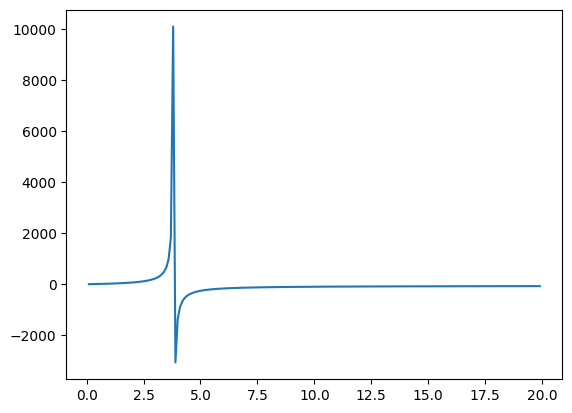

In [322]:
m = ModelProfiler('llama-13b', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson', 1)    # 这里假设已经profile好了，调用这个类只是获取数据

model_profiler_msg = m.profile_data         # model_profiler_msg 包含各个tp的profile数据
decode_test_model = DecodeRateModelV2(
    model_profiler_msg[2]['model_msg'], 
    {
        'qps': 6,
        'prompt_len': 261, # 128, 182, 261
        'output_len': 491, # 256, 473, 491
    }, 
    model_profiler_msg[2]['decode_msg']
)
# decode_test_model.get_decode_time(190.045700)
# decode_test_model.get_out_rate_according_to_batch_size(40.542400)
# print(decode_test_model.get_batch_size_according_to_mu_d(4))
# decode_test_model.get_out_rate_according_to_batch_size(190.045700)
qps = [i/10 for i in range(1,200)]
# mu_d = [decode_test_model.solve_mu_d(q) for q in qps]
bs = [decode_test_model.get_batch_size_according_to_qps(q) for q in qps]
import matplotlib.pyplot as plt
plt.plot(qps, bs)
for q,b in zip(qps,bs):
    print(f"qps: {q}, bs: {b}, step_time: {decode_test_model.get_decode_time(b)}")


### 3.2 迁移模型测试分析

Migration files: ['/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-4_2-1.log']
Lower bound: -145.3830781910155, Upper bound: 939.8915519316992


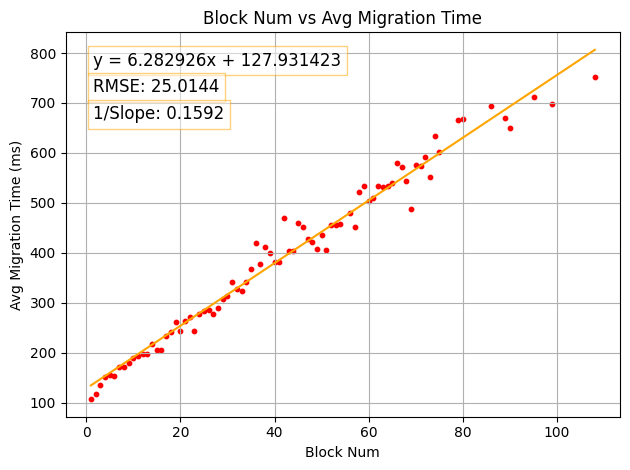

Migration fit results: [  6.28292615 127.93142255]
Migration files: ['/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-10_2-2.log', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-4_2-2.log', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-6_2-2.log', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-2_2-2.log', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-8_2-2.log']
Lower bound: 71.17601484060287, Upper bound: 532.2067531943321


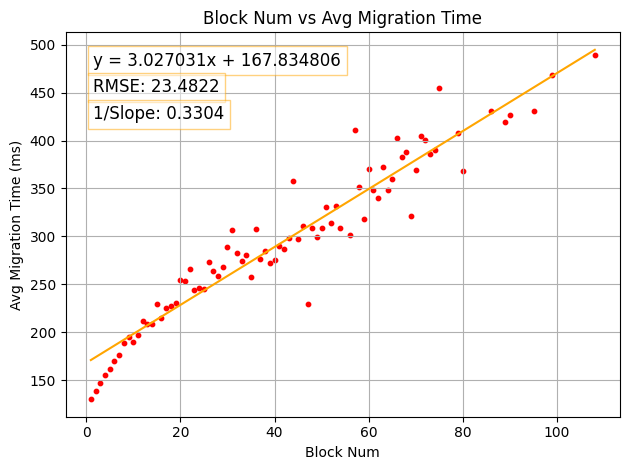

Migration fit results: [  3.02703128 167.83480635]
Migration files: ['/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-4_2-4.log']
Lower bound: 29.08024936914444, Upper bound: 779.20693308115


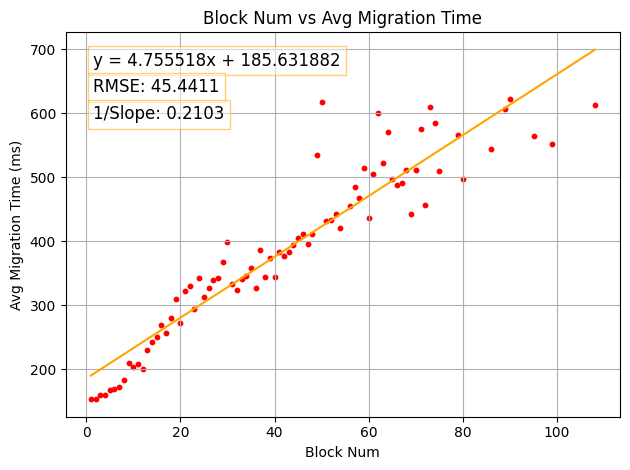

Migration fit results: [  4.75551804 185.631882  ]
Migration files: ['/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-4_4-1.log']
Lower bound: -112.07319708944055, Upper bound: 1036.7518509166282


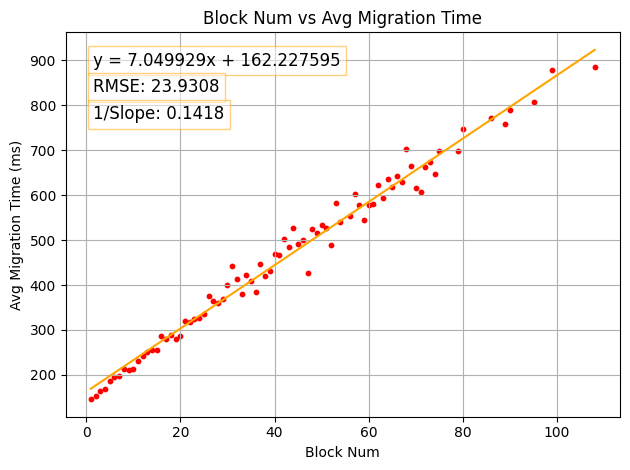

Migration fit results: [  7.04992943 162.22759529]
Migration files: ['/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-4_4-2.log']
Lower bound: -53.23962246378261, Upper bound: 814.3081657588482


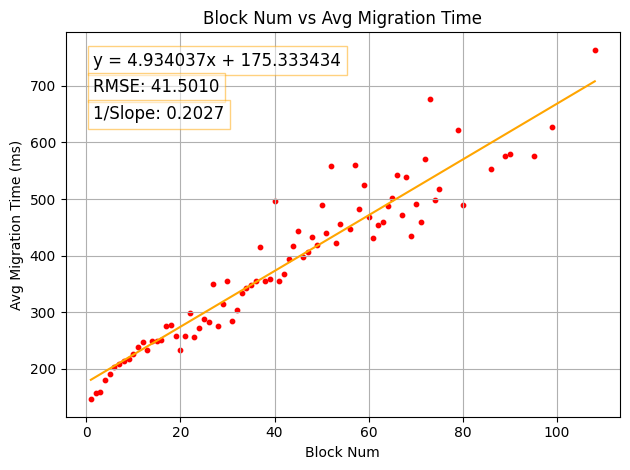

Migration fit results: [  4.9340367  175.33343405]
Migration files: ['/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-6_4-4.log', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-8_4-4.log', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-10_4-4.log', '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1/llama-7b/poisson//benchmark_pdd_2000_qps-4_4-4.log']
Lower bound: 38.7238797214296, Upper bound: 709.2666377623876


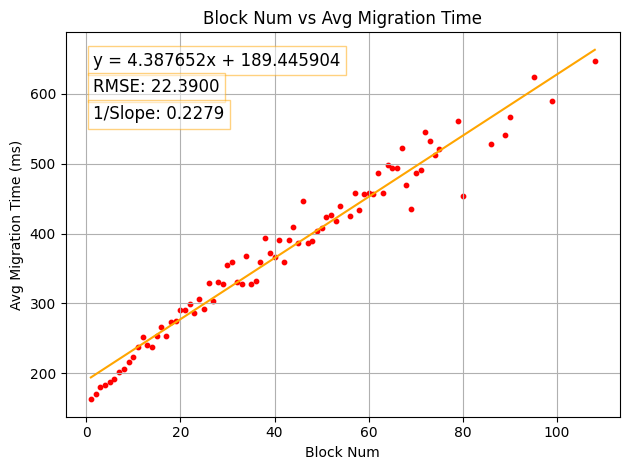

Migration fit results: [  4.38765194 189.44590421]


In [323]:
def get_files_for_migrate_analysis(profile_dir, model_name, from_tp, to_tp=None):
    dir = f'{profile_dir}/{model_name}/poisson/'
    # 列出dir下所有文件
    files = os.listdir(dir)
    # 过滤出包含tp的文件
    files = [f for f in files if f'_pdd_' in f]

    new_files = []
    for f in files:
        tp_list = f.split('_')[4]
        if f'{from_tp}-{to_tp}' in tp_list:
            new_files.append(f)
    new_files = [f for f in new_files if f'.log' in f]
    new_files = [f'{dir}/{f}' for f in new_files]
    # assert len(new_files) > 0, f'No profile files found in {dir} for tp {self.tp}'
    return new_files

def get_migrate_msg(profile_dir, model_name, from_tp):
    concurrency = 1
    # file = [
    #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_6_1_3.log',
    #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_2_1_3.log',
    #     f'{self.profile_dir}/{self.model_name}/poisson/serve_pdd_tp1_2000_qps_4_1_3.log',
    # ]
    for tp in [1, 2, 4]:
        file = get_files_for_migrate_analysis(profile_dir, model_name, from_tp, tp)
        if len(file) == 0:
            continue
        print(f"Migration files: {file}")
        migration_profile = MigrationProfile(file)
        migration_profile.get_migration_info()
        migration_profile.plot_block_num_vs_avg_migration_time()
        print(f"Migration fit results: {migration_profile.fit_results}")
# get_migrate_msg('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1', 'llama-7b', 1)
get_migrate_msg('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1', 'llama-7b', 2)
get_migrate_msg('/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1', 'llama-7b', 4)

In [324]:
profile_dir = '/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-1'
workload_msg = {
    'qps': 4,
    'prompt_len': 182, # 128, 182, 261
    'output_len': 473, # 256, 473, 491
    'is_ShareGPT': False,
}
model = 'llama-7b'
instance_deploy_msg = [     # (prefill_tps, decode_tps)
    # ([1,1,1,1],[]),
    # ([1,],[1,1,1]),
    # ([1,1,],[1,1]),
    # ([1,1,1,],[1]),
    ([4,4,],[]),
]
def get_model(model, workload_msg, instance_deploy_msg, concurrency=1):
    profile_dir = f'/workspace/llm-serve/Llumnix/benchmark_test/logs/A6000-2-concurrency-{concurrency}'
    if not workload_msg['is_ShareGPT']:
        prompt_len = workload_msg['prompt_len']
        output_len = workload_msg['output_len']
        profile_dir += f'-{prompt_len}-{output_len}'
    m = ModelProfiler(model, profile_dir, 1)    # 这里假设已经profile好了，调用这个类只是获取数据
    model_profiler_msg = m.profile_data         # model_profiler_msg 包含各个tp的profile数据

    decode_tps = instance_deploy_msg[1]         # (prefill_tps, decode_tps)
    if len(decode_tps) == 0:
        rate_model = AggregationRateModel(model_profiler_msg, workload_msg, instance_deploy_msg)
    else:
        rate_model = DisaggregationRateModel(model_profiler_msg, workload_msg, instance_deploy_msg)
    return rate_model
rate_model = get_model(model, workload_msg, instance_deploy_msg[0], concurrency=1)
model = rate_model.models[0]
qps_list = [1,2,2.5,3,3.5,4]
x_values = [i  for i in range(-200, 200)]
for qps in qps_list:
    y_values = model.get_value_according_to_lam(qps, x_values,)
    root = model.solve_batch_size(qps)
    # plt.text(root[0], 0, f'root: {root[0]:.2f}', fontsize=12, color='red')
    plt.plot(x_values, y_values, label=f'qps={qps}')
# y=0
plt.axhline(0, color='gray', linestyle='--')
# x=0
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Batch Size')
plt.legend()
plt.show()


AttributeError: 'AggregationRateModelBaseV3' object has no attribute 'get_value_according_to_lam'

In [ ]:
from sympy import symbols, solve

def get_time(a,b,c,token_num):
    return a * token_num**2 + b * token_num + c

def solve_token_num(a,b,c,lam,l_prompt):

    A = a * lam
    B = lam * (b + a * l_prompt)
    C = lam * c + lam * b * l_prompt - 1000 # 1000 because of ms
    D = lam * c * l_prompt
    x = symbols('x')
    roots = solve(A * x**3 + B * x**2 + C * x + D, x)
    # print("SymPy 求解结果：", roots)
    for r in roots:
        if r.is_real and r > 0:
            print("选择的解：", r)

    # 计算二次项系数
    A = lam * b
    B = lam * c + lam * b * l_prompt - 1000
    C = lam * c * l_prompt

    # 判别式计算
    discriminant = B**2 - 4 * A * C

    # 求解公式
    denominator = 2 * A

    # 计算两个解
    mu_d1 = (-B + math.sqrt(discriminant)) / denominator
    mu_d2 = (-B - math.sqrt(discriminant)) / denominator
    print("手动计算结果：", mu_d1, mu_d2)
    print("验证：", get_time(a,b,c,mu_d1), get_time(a,b,c,mu_d2))

    return mu_d1
    
solve_token_num(
    1.813982272157155e-05,
    0.19500457045462616,
    42.874887952601654,
    4,182
)




手动计算结果： 832.0631126893201 48.09205405633522
验证： 217.68972358497854 52.29501290645362


832.0631126893201